In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Drop ID
df = df.drop("customerID", axis=1)

# Clean data
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Encode
df = pd.get_dummies(df)

# Features & target
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Remove leakage
if "Churn_No" in X.columns:
    X = X.drop("Churn_No", axis=1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔥 FIX: handle imbalance
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.78      0.83      1033
        True       0.54      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [4]:
y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7590618336886994
              precision    recall  f1-score   support

       False       0.88      0.78      0.83      1033
        True       0.54      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [6]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.8289986592190338


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
import pandas as pd

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

top10 = (feature_importances.head(10))
print(top10)

TotalCharges                      0.162645
tenure                            0.141092
MonthlyCharges                    0.136151
Contract_Month-to-month           0.050411
PaymentMethod_Electronic check    0.034675
InternetService_Fiber optic       0.030247
OnlineSecurity_No                 0.028757
TechSupport_No                    0.022356
SeniorCitizen                     0.020005
gender_Male                       0.018091
dtype: float64


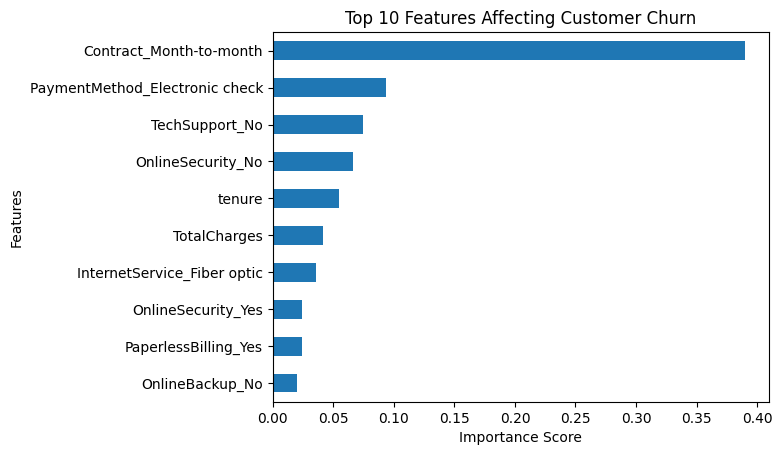

In [16]:
import matplotlib.pyplot as plt

top10.plot(kind="barh")

plt.title("Top 10 Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_resampled, y_train_resampled)

In [ ]:
print(X.columns)


In [11]:
print("Churn_No in features:", "Churn_No" in X.columns)

Churn_No in features: False


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    
    model.fit(X_train_resampled, y_train_resampled)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    print(f"{name}")
    print("Accuracy:", accuracy)
    print("ROC-AUC:", roc)
    print("-"*40)

c:\Users\pranav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.7924662402274343
ROC-AUC: 0.831227254608611
----------------------------------------
Random Forest
Accuracy: 0.9587775408670931
ROC-AUC: 0.9819719316046405
----------------------------------------
Gradient Boosting
Accuracy: 0.7995735607675906
ROC-AUC: 0.8509753016757171
----------------------------------------


In [13]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb")) 


In [ ]:
len(X.columns)

Contract_Month-to-month           0.390136
PaymentMethod_Electronic check    0.093899
TechSupport_No                    0.074867
OnlineSecurity_No                 0.066189
tenure                            0.054368
TotalCharges                      0.041440
InternetService_Fiber optic       0.035844
OnlineSecurity_Yes                0.023934
PaperlessBilling_Yes              0.023858
OnlineBackup_No                   0.020275
dtype: float64


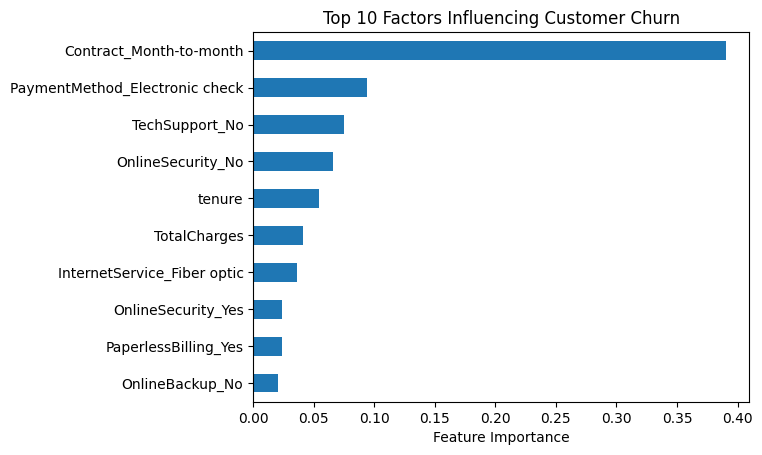

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top10 = importance.head(10)

print(top10)

top10.plot(kind="barh")
plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [15]:
import pickle

with open("../model/churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../model/model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [ ]:
pickle.dump(model, open("../model/churn_model.pkl","wb"))

In [ ]:
pickle.dump(X.columns.tolist(), open("../model/model_columns.pkl","wb"))

In [ ]:
import sys
import sklearn

print(sys.executable)
print(sklearn.__version__)